In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

# --- Setup ---
with open("../../config.yml", "r") as f:
    config = yaml.safe_load(f)

# --- Load indicators panel ---
panel = pd.read_parquet("../../data/processed_data/analysis_panel.parquet")

In [2]:
# --- Panel exploration ---
SELECTED_AREA = "South Yorkshire"  # will search for MCA or constituent LADs

print("=== SHAPE ===")
print(panel.shape)

print("\n=== COLUMNS ===")
for c in panel.columns:
    print(c)

print("\n=== DTYPES ===")
print(panel.dtypes)

print("\n=== SAMPLE ROWS (first 3) ===")
print(panel.head(3).to_string())

print("\n=== UNIQUE YEARS (if year column exists) ===")
year_cols = [c for c in panel.columns if "year" in c.lower()]
if year_cols:
    for yc in year_cols:
        print(f"{yc}: {sorted(panel[yc].unique())}")
else:
    print("No obvious year column found")

print("\n=== GEOGRAPHY COLUMNS ===")
geo_cols = [c for c in panel.columns if any(x in c.lower() for x in ["lad", "area", "region", "mca", "name", "code"])]
for gc in geo_cols:
    print(f"{gc}: {panel[gc].nunique()} unique values")
    print(f"  Sample: {panel[gc].unique()[:5]}")

print("\n=== LQ COLUMNS ===")
lq_cols = [c for c in panel.columns if "lq" in c.lower()]
print(lq_cols)

print("\n=== SOUTH YORKSHIRE ROWS ===")
# Try to find South Yorkshire in whichever geo column exists
for gc in geo_cols:
    sy_rows = panel[panel[gc].astype(str).str.contains("South Yorkshire|Sheffield|Rotherham|Barnsley|Doncaster", case=False, na=False)]
    if len(sy_rows) > 0:
        print(f"Found via column '{gc}':")
        print(sy_rows[geo_cols + lq_cols].to_string())
        break

=== SHAPE ===
(17150, 57)

=== COLUMNS ===
YEAR
GEOGRAPHY_CODE
GEOGRAPHY_NAME
IS8_SECTOR
EMPLOYEES
BUSINESSES
gva_per_hour
weekly_pay
employment_rate
unemployment_rate
gdhi_per_head
new_enterprises
deaths_of_enterprises
active_enterprises
high_growth_enterprises
public_transport_to_employer
drive_to_employer
cycle_to_employer
broadband_availability
4g_area_coverage
ks2_attainment
gcse_by_age_19
ofsted
persistent_absences
persistent_absences_fsm
persistent_absences_cla
early_years_comms
early_years_literacy
early_years_maths
fe_and_skills_achievements
apprenticeship_starts
apprenticeship_achievements
level_3+_qualifications
fe_and_skills_participation
female_hle
male_hle
smokers
reception_obesity
year_6_obesity
adult_obesity
cancer_diagnosis
under_75_mortality_rate
life_satisfaction
worthwhile
happiness
anxiety
net_additions
lq_bus
emp_share
lq_emp
growth_emp
cagr_emp
growth_bus
cagr_bus
related_variety
size_large_share
size_micro_share

=== DTYPES ===
YEAR                              

In [2]:
# ============================================================
# CELL 1 — MCA-level IS8 footprint (Step 1)
# Recompute LQs by aggregating raw EMPLOYEES/BUSINESSES to MCA
# ============================================================

SY_CODES = ["E08000016", "E08000017", "E08000018", "E08000019"]
YEAR = 2022

df = panel[panel["YEAR"] == YEAR].copy()

# National totals per sector
nat = df.groupby("IS8_SECTOR")[["EMPLOYEES", "BUSINESSES"]].sum().rename(
    columns={"EMPLOYEES": "nat_emp", "BUSINESSES": "nat_bus"}
)
nat_total_emp = df["EMPLOYEES"].sum()
nat_total_bus = df["BUSINESSES"].sum()

# MCA totals per sector
sy = df[df["GEOGRAPHY_CODE"].isin(SY_CODES)].groupby("IS8_SECTOR")[["EMPLOYEES", "BUSINESSES"]].sum().rename(
    columns={"EMPLOYEES": "sy_emp", "BUSINESSES": "sy_bus"}
)
sy_total_emp = sy["sy_emp"].sum()
sy_total_bus = sy["sy_bus"].sum()

# Merge and compute LQs
footprint = sy.join(nat)
footprint["lq_emp_mca"] = (footprint["sy_emp"] / sy_total_emp) / (footprint["nat_emp"] / nat_total_emp)
footprint["lq_bus_mca"] = (footprint["sy_bus"] / sy_total_bus) / (footprint["nat_bus"] / nat_total_bus)
footprint["emp_bus_gap"] = footprint["lq_emp_mca"] - footprint["lq_bus_mca"]

footprint = footprint.sort_values("lq_emp_mca", ascending=False)

print("=== SOUTH YORKSHIRE MCA — IS8 FOOTPRINT (2022) ===")
print(f"{'Sector':<40} {'LQ emp':>8} {'LQ bus':>8} {'Gap (e-b)':>10}  Signal")
print("-" * 80)
for sector, row in footprint.iterrows():
    lq_e = row["lq_emp_mca"]
    lq_b = row["lq_bus_mca"]
    gap  = row["emp_bus_gap"]
    if lq_e > 1.25:
        signal = "ANCHOR"
    elif lq_e > 1.0:
        signal = "above avg"
    elif lq_e > 0.75:
        signal = "below avg"
    else:
        signal = "absent/weak"
    print(f"{sector:<40} {lq_e:>8.2f} {lq_b:>8.2f} {gap:>10.2f}  {signal}")

=== SOUTH YORKSHIRE MCA — IS8 FOOTPRINT (2022) ===
Sector                                     LQ emp   LQ bus  Gap (e-b)  Signal
--------------------------------------------------------------------------------
Life Sciences                                1.51     1.33       0.18  ANCHOR
Advanced Manufacturing                       1.16     1.69      -0.53  above avg
Professional and Business Services           1.09     1.01       0.08  above avg
Financial Services                           1.05     1.09      -0.04  above avg
Digital and Technologies                     0.85     1.01      -0.16  below avg
Creative Industries                          0.74     0.85      -0.12  absent/weak
Defence                                      0.00     0.00       0.00  absent/weak


In [5]:
# ============================================================
# CELL 2 — Trajectory analysis (Step 2)
# Use cagr_emp / cagr_bus already in panel (2016–2022 window)
# ============================================================

# Take most recent year per LAD×sector for CAGR (it covers full window)
traj = panel[
    (panel["GEOGRAPHY_CODE"].isin(SY_CODES)) & (panel["YEAR"] == YEAR)
].groupby("IS8_SECTOR")[["cagr_emp", "cagr_bus", "growth_emp", "growth_bus"]].mean()

# National median CAGR for comparison
nat_traj = panel[panel["YEAR"] == YEAR].groupby("IS8_SECTOR")[["cagr_emp", "cagr_bus"]].median().rename(
    columns={"cagr_emp": "nat_med_cagr_emp", "cagr_bus": "nat_med_cagr_bus"}
)

traj = traj.join(nat_traj)
traj["vs_nat_emp"] = traj["cagr_emp"] - traj["nat_med_cagr_emp"]
traj["vs_nat_bus"] = traj["cagr_bus"] - traj["nat_med_cagr_bus"]

print("\n=== TRAJECTORY (CAGR 2016–2022, SY MCA avg vs national median) ===")
print(f"{'Sector':<40} {'CAGR emp':>9} {'CAGR bus':>9} {'vs nat emp':>11} {'vs nat bus':>11}  Trajectory")
print("-" * 100)
for sector, row in traj.sort_values("cagr_emp", ascending=False).iterrows():
    ce = float(row["cagr_emp"]) if pd.notna(row["cagr_emp"]) else None
    cb = float(row["cagr_bus"]) if pd.notna(row["cagr_bus"]) else None
    ve = float(row["vs_nat_emp"]) if pd.notna(row["vs_nat_emp"]) else None
    vb = float(row["vs_nat_bus"]) if pd.notna(row["vs_nat_bus"]) else None

    if ce is None or ve is None:
        traj_label = "no data"
    elif ce > 0.03 and ve > 0:
        traj_label = "GROWING (above nat)"
    elif ce > 0 and ve < 0:
        traj_label = "growing (below nat)"
    elif ce < 0 and ve < 0:
        traj_label = "DECLINING"
    else:
        traj_label = "mixed"

    ce_s = f"{ce:>9.3f}" if ce is not None else f"{'NA':>9}"
    cb_s = f"{cb:>9.3f}" if cb is not None else f"{'NA':>9}"
    ve_s = f"{ve:>11.3f}" if ve is not None else f"{'NA':>11}"
    vb_s = f"{vb:>11.3f}" if vb is not None else f"{'NA':>11}"
    print(f"{sector:<40} {ce_s} {cb_s} {ve_s} {vb_s}  {traj_label}")


=== TRAJECTORY (CAGR 2016–2022, SY MCA avg vs national median) ===
Sector                                    CAGR emp  CAGR bus  vs nat emp  vs nat bus  Trajectory
----------------------------------------------------------------------------------------------------
Life Sciences                                0.126    -0.059       0.107      -0.059  GROWING (above nat)
Advanced Manufacturing                       0.039     0.016       0.047       0.016  GROWING (above nat)
Financial Services                           0.019     0.011       0.032       0.011  mixed
Creative Industries                          0.005     0.010      -0.008       0.011  growing (below nat)
Professional and Business Services           0.002    -0.012      -0.009      -0.007  growing (below nat)
Digital and Technologies                    -0.005    -0.004      -0.006       0.015  DECLINING
Defence                                         NA        NA          NA          NA  no data


In [6]:
# ============================================================
# CELL 3 — Correlate scorecard (Step 3)
#
# PURPOSE:
# The national regression tells us which local conditions are
# associated with IS8 sector presence across all LADs. This cell
# takes those same variables and asks: how does South Yorkshire
# score on each one, relative to the national median?
#
# This is the bridge between the national analysis (Phase 1) and
# the local area assessment. A variable where SY scores ABOVE the
# national median is a potential asset; BELOW is a potential gap
# or barrier.
#
# NOTE: CORRELATE_VARS below is currently a placeholder using
# theoretically sensible predictors. Once the regression is
# complete, replace this list with the variables that came out
# as statistically significant — ideally sector by sector if
# different variables matter for different IS8 sectors.
# ============================================================

CORRELATE_VARS = [
    "level_3+_qualifications",    # skills pipeline — key for knowledge-intensive sectors
    "apprenticeship_starts",      # technical skills supply
    "broadband_availability",     # digital infrastructure
    "4g_area_coverage",           # connectivity
    "drive_to_employer",          # labour market accessibility
    "public_transport_to_employer",
    "active_enterprises",         # enterprise base density
    "high_growth_enterprises",    # dynamism of local business base
    "new_enterprises",            # entrepreneurial churn
    "unemployment_rate",          # labour market slack (higher = more flexibility)
    "fe_and_skills_achievements", # workforce upskilling capacity
]

# --- Step 3a: Extract LAD-level values for 2022 ---
# Correlate variables are LAD-level (not sector-specific), so they repeat
# identically across all IS8_SECTOR rows for a given LAD and year.
# We drop duplicates to get one row per LAD before doing any aggregation.
lad_vars = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")[["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"] + CORRELATE_VARS]
    .set_index("GEOGRAPHY_CODE")
)

# --- Step 3b: Compute national median across all 350 LADs ---
# We use median rather than mean because many variables are right-skewed
# (e.g. enterprise counts are pulled up by large urban centres like London).
nat_medians = lad_vars[CORRELATE_VARS].median()

# --- Step 3c: Average the 4 SY LADs into one MCA-level figure ---
# Simple unweighted mean across Barnsley, Doncaster, Rotherham, Sheffield.
# This treats each LAD equally — a population-weighted version would be
# more precise but requires an extra population lookup.
sy_means = lad_vars.loc[SY_CODES, CORRELATE_VARS].mean()

# --- Step 3d: Build the scorecard ---
# % diff = how far SY sits above or below the national median.
# Threshold of ±5% for ABOVE/BELOW is a practical judgement call —
# tighten or loosen depending on how much variation exists in each variable.
scorecard = pd.DataFrame({
    "SY_mean":    sy_means,
    "nat_median": nat_medians,
})
scorecard["pct_diff"] = (scorecard["SY_mean"] - scorecard["nat_median"]) / scorecard["nat_median"] * 100
scorecard["position"] = scorecard["pct_diff"].apply(
    lambda x: "ABOVE ▲" if x > 5 else ("BELOW ▼" if x < -5 else "~PARITY")
)

print("\n=== CORRELATE SCORECARD — SY MCA vs NATIONAL MEDIAN (2022) ===")
print("(Placeholder variables — replace with regression-significant predictors once available)\n")
print(f"{'Variable':<35} {'SY mean':>10} {'Nat median':>12} {'% diff':>8}  Position")
print("-" * 85)
for var, row in scorecard.iterrows():
    print(f"{var:<35} {row['SY_mean']:>10.2f} {row['nat_median']:>12.2f} {row['pct_diff']:>8.1f}%  {row['position']}")


=== CORRELATE SCORECARD — SY MCA vs NATIONAL MEDIAN (2022) ===
(Placeholder variables — replace with regression-significant predictors once available)

Variable                               SY mean   Nat median   % diff  Position
-------------------------------------------------------------------------------------
level_3+_qualifications                  55.08        60.40     -8.8%  BELOW ▼
apprenticeship_starts                  1014.25       945.50      7.3%  ABOVE ▲
broadband_availability                   77.00        77.15     -0.2%  ~PARITY
4g_area_coverage                         98.59        99.99     -1.4%  ~PARITY
drive_to_employer                         7.78         7.56      2.8%  ~PARITY
public_transport_to_employer             11.88        11.18      6.2%  ABOVE ▲
active_enterprises                    11626.25      5880.00     97.7%  ABOVE ▲
high_growth_enterprises                  40.00        25.00     60.0%  ABOVE ▲
new_enterprises                        1636.25    

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CELL 4a — Prepare clustering dataset
#
# We cluster on rates/proportions only to avoid the size-bias
# problem where larger LADs (Sheffield) dominate on raw counts.
# All variables below are bounded or expressed as shares/rates.
# ============================================================

CLUSTER_VARS = [
    "unemployment_rate",          # labour market slack
    "level_3+_qualifications",    # higher skills share
    "gcse_by_age_19",             # secondary education attainment rate
    "apprenticeship_achievements",# technical skills pipeline (rate per provision)
    "broadband_availability",     # digital infrastructure coverage %
    "4g_area_coverage",           # mobile connectivity coverage %
    "drive_to_employer",          # % of jobs accessible by car
    "public_transport_to_employer",# % of jobs accessible by PT
    "cycle_to_employer",          # % of jobs accessible by cycle
    "size_large_share",           # share of large firms in local business base
    "size_micro_share",           # share of micro firms
    "ofsted",                     # education quality rate
    "persistent_absences",        # school engagement rate (inverse)
]

FOCUS_SECTORS = ["Life Sciences", "Advanced Manufacturing", "Digital and Technologies"]
YEAR = 2022

# Extract one row per LAD (cluster vars are sector-invariant)
lad_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

# Drop LADs with any missing values in cluster vars
before = len(lad_df)
lad_df = lad_df.dropna(subset=CLUSTER_VARS)
after = len(lad_df)
print(f"LADs retained after dropping missing: {after}/{before}")

# Standardise — essential for KMeans so no variable dominates by scale
scaler = StandardScaler()
X = scaler.fit_transform(lad_df[CLUSTER_VARS])

print(f"\nClustering on {len(CLUSTER_VARS)} variables across {after} LADs")
print("Variables:", CLUSTER_VARS)

LADs retained after dropping missing: 112/350

Clustering on 13 variables across 112 LADs
Variables: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share', 'ofsted', 'persistent_absences']


In [ ]:
# ============================================================
# CELL 4a (diagnostic) — Why are so many LADs being dropped?
#
# dropna removes a LAD if ANY variable is missing. One sparsely
# covered variable can silently eliminate hundreds of LADs.
# This cell finds the culprits so we can make an informed
# decision about which variables to keep.
# ============================================================

lad_df_full = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

print("=== MISSING VALUES PER VARIABLE ===")
print(f"{'Variable':<35} {'Missing':>8} {'% missing':>10}  {'Coverage':>10}")
print("-" * 70)
for var in CLUSTER_VARS:
    n_miss = lad_df_full[var].isna().sum()
    pct    = n_miss / len(lad_df_full) * 100
    bar    = "█" * int((100 - pct) / 5)
    print(f"{var:<35} {n_miss:>8} {pct:>9.1f}%  {bar}")

print(f"\nTotal LADs: {len(lad_df_full)}")
print(f"Complete cases (no missing on any var): {lad_df_full.dropna(subset=CLUSTER_VARS).shape[0]}")

# Show how many LADs are retained if we drop each variable one at a time
print("\n=== IMPACT OF REMOVING EACH VARIABLE ===")
print("(How many LADs would be retained if this variable were excluded?)")
print(f"{'Variable dropped':<35} {'LADs retained':>15}")
print("-" * 55)
for var in CLUSTER_VARS:
    remaining_vars = [v for v in CLUSTER_VARS if v != var]
    retained = lad_df_full.dropna(subset=remaining_vars).shape[0]
    print(f"{var:<35} {retained:>15}")

# Also check SY LADs specifically
print("\n=== MISSING VALUES FOR SY LADs SPECIFICALLY ===")
sy_full = lad_df_full.loc[[c for c in SY_CODES if c in lad_df_full.index]]
print(sy_full[CLUSTER_VARS].isnull().sum().to_string())

=== MISSING VALUES PER VARIABLE ===
Variable                             Missing  % missing    Coverage
----------------------------------------------------------------------
unemployment_rate                         21       6.0%  ██████████████████
level_3+_qualifications                    6       1.7%  ███████████████████
gcse_by_age_19                            59      16.9%  ████████████████
apprenticeship_achievements               55      15.7%  ████████████████
broadband_availability                     4       1.1%  ███████████████████
4g_area_coverage                           4       1.1%  ███████████████████
drive_to_employer                         71      20.3%  ███████████████
public_transport_to_employer              71      20.3%  ███████████████
cycle_to_employer                         71      20.3%  ███████████████
size_large_share                           1       0.3%  ███████████████████
size_micro_share                           1       0.3%  █████████████████

In [10]:
# ============================================================
# CELL 4a (fix) — test variable combinations for coverage
#
# The single-variable removal table was misleading because
# missing patterns overlap. Here we test dropping combinations
# of low-coverage variables to find the best tradeoff between
# variable richness and LAD coverage.
# ============================================================

# Variables with high missingness — candidates for removal
HIGH_MISSING = ["ofsted", "persistent_absences"]
MED_MISSING  = ["drive_to_employer", "public_transport_to_employer", "cycle_to_employer",
                 "gcse_by_age_19", "apprenticeship_achievements"]

print("=== COVERAGE UNDER DIFFERENT VARIABLE SETS ===\n")

test_sets = {
    "All 13 vars (baseline)":
        CLUSTER_VARS,
    "Drop ofsted + persistent_absences":
        [v for v in CLUSTER_VARS if v not in HIGH_MISSING],
    "Drop ofsted + persistent_absences + transport (3 vars)":
        [v for v in CLUSTER_VARS if v not in HIGH_MISSING + ["drive_to_employer", "public_transport_to_employer", "cycle_to_employer"]],
    "Drop ofsted + persistent_absences + gcse + apprenticeship":
        [v for v in CLUSTER_VARS if v not in HIGH_MISSING + ["gcse_by_age_19", "apprenticeship_achievements"]],
    "Drop all high+med missing (minimal set)":
        [v for v in CLUSTER_VARS if v not in HIGH_MISSING + MED_MISSING],
}

for label, var_set in test_sets.items():
    retained = lad_df_full.dropna(subset=var_set).shape[0]
    sy_retained = lad_df_full.loc[
        [c for c in SY_CODES if c in lad_df_full.index]
    ].dropna(subset=var_set).shape[0]
    print(f"{label}")
    print(f"  Variables: {len(var_set)}  |  LADs retained: {retained}/350  |  SY LADs: {sy_retained}/4")
    print(f"  Vars: {var_set}\n")

=== COVERAGE UNDER DIFFERENT VARIABLE SETS ===

All 13 vars (baseline)
  Variables: 13  |  LADs retained: 112/350  |  SY LADs: 4/4
  Vars: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share', 'ofsted', 'persistent_absences']

Drop ofsted + persistent_absences
  Variables: 11  |  LADs retained: 270/350  |  SY LADs: 4/4
  Vars: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share']

Drop ofsted + persistent_absences + transport (3 vars)
  Variables: 8  |  LADs retained: 275/350  |  SY LADs: 4/4
  Vars: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_ach

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CELL 4a — Prepare clustering dataset
#
# We cluster on rates/proportions only to avoid the size-bias
# problem where larger LADs (Sheffield) dominate on raw counts.
# All variables below are bounded or expressed as shares/rates.
# ============================================================

CLUSTER_VARS = [
    "unemployment_rate",          # labour market slack
    "level_3+_qualifications",    # higher skills share
    "gcse_by_age_19",             # secondary education attainment rate
    "apprenticeship_achievements",# technical skills pipeline (rate per provision)
    "broadband_availability",     # digital infrastructure coverage %
    "4g_area_coverage",           # mobile connectivity coverage %
    "drive_to_employer",          # % of jobs accessible by car
    "public_transport_to_employer",# % of jobs accessible by PT
    "cycle_to_employer",          # % of jobs accessible by cycle
    "size_large_share",           # share of large firms in local business base
    "size_micro_share",           # share of micro firms
    # ofsted and persistent_absences dropped — 63% missing each, and both
    # are school-level measures with a 15-20 year lag to the workforce.
    # Dropping them recovers 270/350 LADs vs 112 with no meaningful
    # loss to the EEG-based analytical framework.
]

FOCUS_SECTORS = ["Life Sciences", "Advanced Manufacturing", "Digital and Technologies"]
YEAR = 2022

# Extract one row per LAD (cluster vars are sector-invariant)
lad_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

# Drop LADs with any missing values in cluster vars
before = len(lad_df)
lad_df = lad_df.dropna(subset=CLUSTER_VARS)
after = len(lad_df)
print(f"LADs retained after dropping missing: {after}/{before}")

# Standardise — essential for KMeans so no variable dominates by scale
scaler = StandardScaler()
X = scaler.fit_transform(lad_df[CLUSTER_VARS])

print(f"\nClustering on {len(CLUSTER_VARS)} variables across {after} LADs")
print("Variables:", CLUSTER_VARS)

LADs retained after dropping missing: 270/350

Clustering on 11 variables across 270 LADs
Variables: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share']


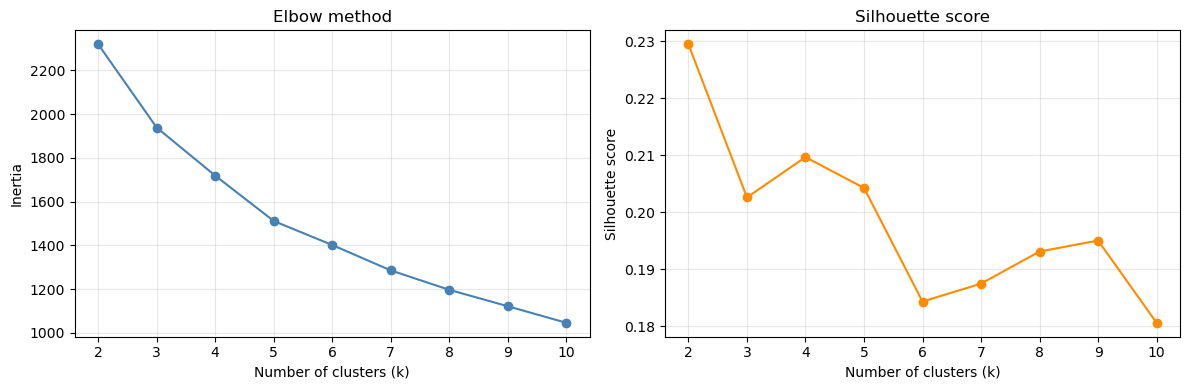


Silhouette scores by k:
  k=2: 0.2295
  k=3: 0.2026
  k=4: 0.2097
  k=5: 0.2043
  k=6: 0.1844
  k=7: 0.1875
  k=8: 0.1931
  k=9: 0.1951
  k=10: 0.1806


In [12]:
# ============================================================
# CELL 4b — Choose number of clusters (elbow + silhouette)
#
# We test k=2..10. Elbow looks for where inertia stops falling
# sharply. Silhouette measures how well-separated clusters are
# (higher = better, max=1). Pick k where both agree.
# ============================================================

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertias, "o-", color="steelblue")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow method")
ax1.grid(alpha=0.3)

ax2.plot(list(k_range), silhouettes, "o-", color="darkorange")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette score")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette scores by k:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

In [13]:
# ============================================================
# CELL 4c — Fit final model and find SY comparators
#
# Set K below based on the elbow/silhouette output from 4b.
# Then for each SY LAD and each focus sector, we find other
# LADs in the same cluster with higher IS8 LQ — these are the
# "similar conditions, better outcomes" comparators.
# ============================================================

K = 4  # <-- adjust after inspecting 4b output

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
lad_df["cluster"] = km_final.fit_predict(X)

# Attach LQ values (one per LAD×sector) for the focus sectors
lq_lookup = (
    panel[
        (panel["YEAR"] == YEAR) &
        (panel["IS8_SECTOR"].isin(FOCUS_SECTORS))
    ]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])
    [["lq_emp", "lq_bus"]]
)

print(f"\n=== CLUSTER MEMBERSHIPS — SY LADs (k={K}) ===")
for code in SY_CODES:
    if code in lad_df.index:
        name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
        cluster = lad_df.loc[code, "cluster"]
        print(f"  {name} ({code}): Cluster {cluster}")

print(f"\n=== COMPARATOR LADs — same cluster, higher LQ emp (top 5 per sector) ===")
for code in SY_CODES:
    if code not in lad_df.index:
        continue
    name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
    cluster = lad_df.loc[code, "cluster"]
    cluster_lads = lad_df[lad_df["cluster"] == cluster].index.tolist()

    print(f"\n--- {name} (Cluster {cluster}, n={len(cluster_lads)} LADs) ---")

    for sector in FOCUS_SECTORS:
        # Get LQ for all LADs in same cluster
        cluster_lqs = (
            lq_lookup.xs(sector, level="IS8_SECTOR")
            .reindex(cluster_lads)
            .dropna()
            .sort_values("lq_emp", ascending=False)
        )
        # SY LAD's own LQ
        sy_lq = lq_lookup.xs(sector, level="IS8_SECTOR").loc[code, "lq_emp"] if code in lq_lookup.xs(sector, level="IS8_SECTOR").index else None

        # Top 5 comparators with higher LQ (excluding the SY LAD itself)
        comparators = cluster_lqs[
            (cluster_lqs.index != code) &
            (cluster_lqs["lq_emp"] > (sy_lq if sy_lq else 0))
        ].head(5)

        print(f"\n  [{sector}] — {name} lq_emp: {sy_lq:.2f}" if sy_lq else f"\n  [{sector}] — {name} lq_emp: N/A")
        if len(comparators) == 0:
            print("    No comparators with higher LQ in same cluster")
        else:
            print(f"  {'LAD':<30} {'lq_emp':>8} {'lq_bus':>8}")
            for comp_code, comp_row in comparators.iterrows():
                comp_name = lad_df.loc[comp_code, "GEOGRAPHY_NAME"] if comp_code in lad_df.index else comp_code
                print(f"  {comp_name:<30} {comp_row['lq_emp']:>8.2f} {comp_row['lq_bus']:>8.2f}")


=== CLUSTER MEMBERSHIPS — SY LADs (k=4) ===
  Barnsley (E08000016): Cluster 0
  Doncaster (E08000017): Cluster 0
  Rotherham (E08000018): Cluster 0
  Sheffield (E08000019): Cluster 0

=== COMPARATOR LADs — same cluster, higher LQ emp (top 5 per sector) ===

--- Barnsley (Cluster 0, n=121 LADs) ---

  [Life Sciences] — Barnsley lq_emp: 0.42
  LAD                              lq_emp   lq_bus
  Broxtowe                           7.66     0.00
  Vale of White Horse                7.42     3.95
  Halton                             5.78     2.26
  Swindon                            4.83     0.38
  Crawley                            4.35     0.72

  [Advanced Manufacturing] — Barnsley lq_emp: 0.77
  LAD                              lq_emp   lq_bus
  Tewkesbury                         7.20     1.92
  Derby                              5.70     1.11
  South Gloucestershire              4.44     1.22
  Sunderland                         4.30     1.40
  Plymouth                           3.94   

LADs retained after dropping missing: 270/350

Clustering on 11 variables across 270 LADs
Variables: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share']


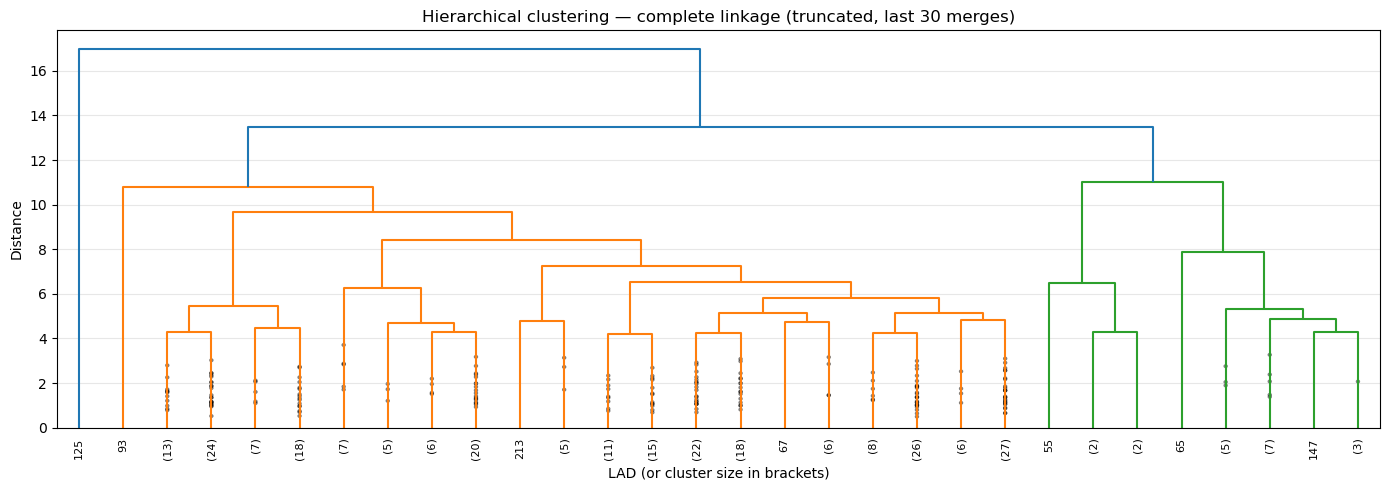

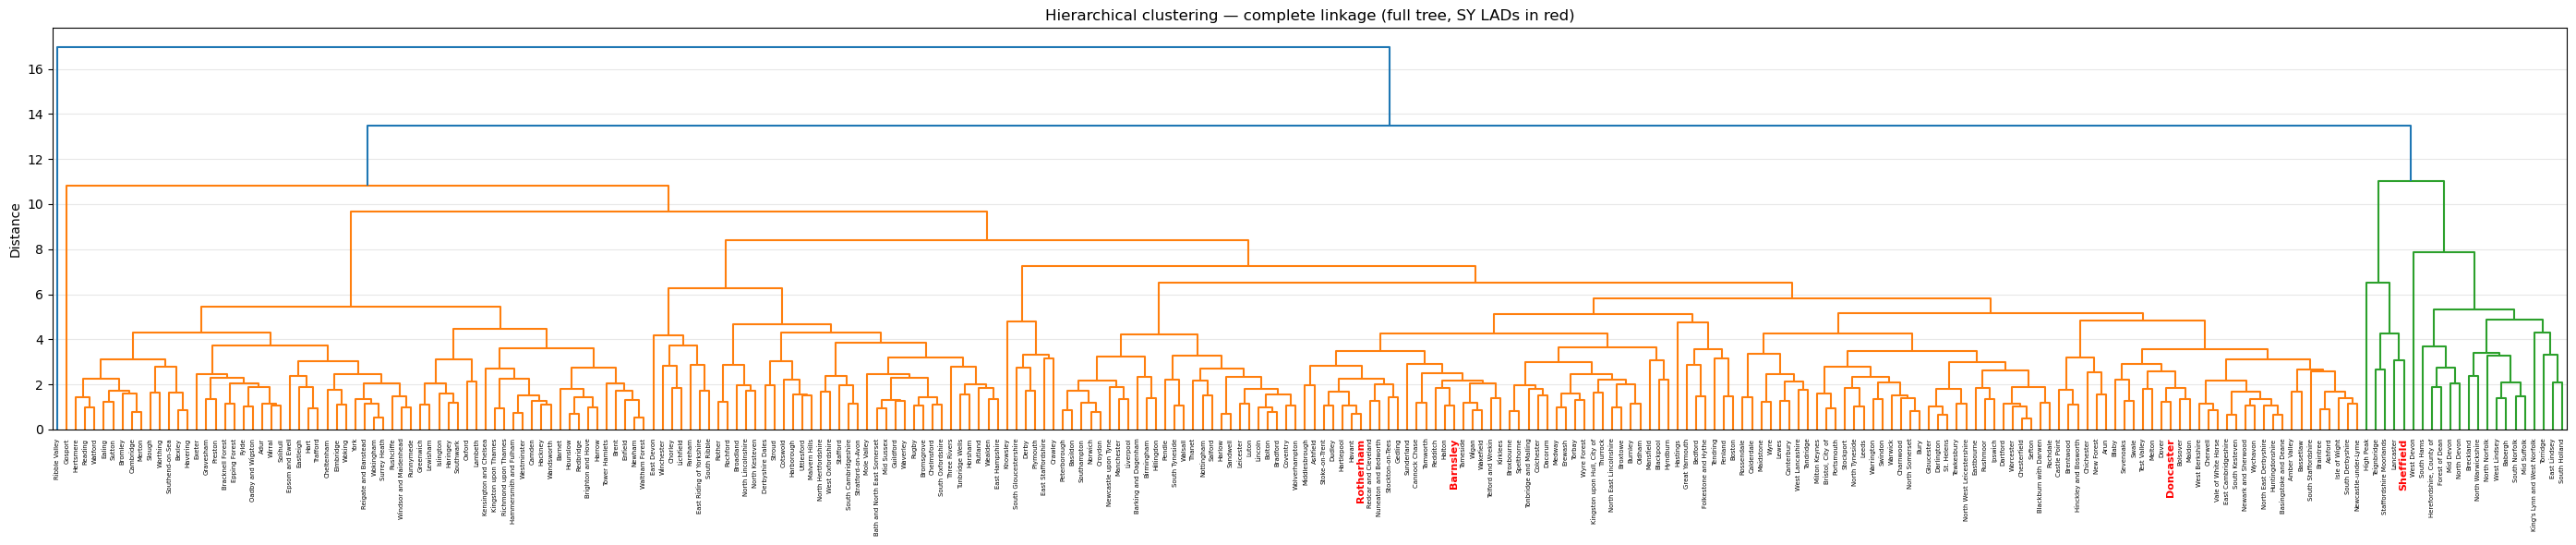

SY LADs positions in leaf order:
  Barnsley: leaf position 150/270
  Doncaster: leaf position 227/270
  Rotherham: leaf position 140/270
  Sheffield: leaf position 252/270
=== TREE CUT AT t=3.5 ===
Number of clusters formed: 40

Cluster sizes (top 15 largest):
  Cluster 26: 26 LADs
  Cluster 29: 18 LADs
  Cluster 20: 15 LADs
  Cluster 17: 15 LADs
  Cluster 13: 15 LADs
  Cluster 3: 14 LADs
  Cluster 1: 13 LADs
  Cluster 18: 11 LADs
  Cluster 19: 11 LADs
  Cluster 16: 11 LADs
  Cluster 2: 10 LADs
  Cluster 6: 10 LADs
  Cluster 28: 9 LADs
  Cluster 25: 8 LADs
  Cluster 5: 8 LADs

=== CLUSTER MEMBERSHIPS — SY LADs ===
  Barnsley (E08000016): Cluster 19  (n=11 LADs)
  Doncaster (E08000017): Cluster 28  (n=9 LADs)
  Rotherham (E08000018): Cluster 18  (n=11 LADs)
  Sheffield (E08000019): Cluster 32  (n=2 LADs)

=== COMPARATOR LADs — same cluster, higher LQ emp (top 5 per sector) ===

--- Barnsley (Cluster 19, n=11 LADs) ---
    All LADs in cluster: ['Halton', 'Telford and Wrekin', 'Cannock Ch

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CELL 4a — Prepare clustering dataset
#
# We cluster on rates/proportions only to avoid the size-bias
# problem where larger LADs (Sheffield) dominate on raw counts.
# All variables below are bounded or expressed as shares/rates.
# ============================================================

CLUSTER_VARS = [
    "unemployment_rate",          # labour market slack
    "level_3+_qualifications",    # higher skills share
    "gcse_by_age_19",             # secondary education attainment rate
    "apprenticeship_achievements",# technical skills pipeline (rate per provision)
    "broadband_availability",     # digital infrastructure coverage %
    "4g_area_coverage",           # mobile connectivity coverage %
    "drive_to_employer",          # % of jobs accessible by car
    "public_transport_to_employer",# % of jobs accessible by PT
    "cycle_to_employer",          # % of jobs accessible by cycle
    "size_large_share",           # share of large firms in local business base
    "size_micro_share",           # share of micro firms
    # ofsted and persistent_absences dropped — 63% missing each, and both
    # are school-level measures with a 15-20 year lag to the workforce.
    # Dropping them recovers 270/350 LADs vs 112 with no meaningful
    # loss to the EEG-based analytical framework.
]

FOCUS_SECTORS = ["Life Sciences", "Advanced Manufacturing", "Digital and Technologies"]
YEAR = 2022

# Extract one row per LAD (cluster vars are sector-invariant)
lad_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

# Drop LADs with any missing values in cluster vars
before = len(lad_df)
lad_df = lad_df.dropna(subset=CLUSTER_VARS)
after = len(lad_df)
print(f"LADs retained after dropping missing: {after}/{before}")

# Standardise — essential for KMeans so no variable dominates by scale
scaler = StandardScaler()
X = scaler.fit_transform(lad_df[CLUSTER_VARS])

print(f"\nClustering on {len(CLUSTER_VARS)} variables across {after} LADs")
print("Variables:", CLUSTER_VARS)


# ============================================================
# CELL 4b — Hierarchical clustering + dendrogram
#
# Complete linkage: clusters are merged based on the maximum
# distance between any two points across clusters. This produces
# tighter, more compact clusters than Ward or Average — better
# for finding genuinely similar comparators rather than just
# broadly similar groups.
#
# We show two views:
#   (1) Truncated dendrogram — last 30 merges, readable structure
#   (2) Full dendrogram — all 270 LADs, SY LADs highlighted in red
# ============================================================

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Build linkage matrix — this encodes the full tree
Z = linkage(X, method="complete", metric="euclidean")

# --- Helper: colour SY LADs red in full dendrogram ---
lad_names  = lad_df.index.tolist()          # ordered list of LAD codes after dropna
lad_labels = lad_df["GEOGRAPHY_NAME"].tolist()
sy_indices = [lad_names.index(c) for c in SY_CODES if c in lad_names]
sy_label_names = [lad_df.loc[c, "GEOGRAPHY_NAME"] for c in SY_CODES if c in lad_names]

def leaf_colour(leaf_id):
    return "red" if leaf_id in sy_indices else "black"

# ── Plot 1: Truncated dendrogram (last 30 merges) ──────────────────
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    ax=ax,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2]),
)
ax.set_title("Hierarchical clustering — complete linkage (truncated, last 30 merges)")
ax.set_xlabel("LAD (or cluster size in brackets)")
ax.set_ylabel("Distance")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("dendrogram_truncated.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Full dendrogram with SY LADs highlighted ──────────────
fig, ax = plt.subplots(figsize=(28, 6))
ddata = dendrogram(
    Z,
    ax=ax,
    labels=lad_labels,
    leaf_rotation=90,
    leaf_font_size=5,
    color_threshold=0.7 * max(Z[:, 2]),
    no_plot=False,
)
# Colour SY LAD labels red
for lbl in ax.get_xticklabels():
    if lbl.get_text() in sy_label_names:
        lbl.set_color("red")
        lbl.set_fontsize(8)
        lbl.set_fontweight("bold")
ax.set_title("Hierarchical clustering — complete linkage (full tree, SY LADs in red)")
ax.set_ylabel("Distance")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("dendrogram_full.png", dpi=150, bbox_inches="tight")
plt.show()

print("SY LADs positions in leaf order:")
leaf_order = ddata["leaves"]
for idx in sy_indices:
    pos = leaf_order.index(idx)
    print(f"  {lad_df.iloc[idx]['GEOGRAPHY_NAME']}: leaf position {pos}/270")


# ============================================================
# CELL 4c — Cut the tree and find comparators
#
# Instead of fixing K upfront, we cut the dendrogram at a
# distance threshold t. Every LAD whose branch connects to
# an SY LAD below that threshold is a comparator candidate.
#
# T_CUT controls granularity:
#   - Higher t → larger, looser clusters (more comparators)
#   - Lower t  → smaller, tighter clusters (fewer, closer comparators)
#
# Start with t = 3.5 and adjust based on cluster sizes printed below.
# A good cut gives SY clusters of ~10-30 LADs.
# ============================================================

T_CUT = 3.5  # <-- adjust after inspecting dendrogram

labels_hier = fcluster(Z, t=T_CUT, criterion="distance")
lad_df["cluster"] = labels_hier

print(f"=== TREE CUT AT t={T_CUT} ===")
print(f"Number of clusters formed: {labels_hier.max()}")
print(f"\nCluster sizes (top 15 largest):")
sizes = pd.Series(labels_hier).value_counts().head(15)
for cid, cnt in sizes.items():
    print(f"  Cluster {cid}: {cnt} LADs")

print(f"\n=== CLUSTER MEMBERSHIPS — SY LADs ===")
for code in SY_CODES:
    if code in lad_df.index:
        name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
        cluster = lad_df.loc[code, "cluster"]
        size    = (labels_hier == cluster).sum()
        print(f"  {name} ({code}): Cluster {cluster}  (n={size} LADs)")

print(f"\n=== COMPARATOR LADs — same cluster, higher LQ emp (top 5 per sector) ===")
for code in SY_CODES:
    if code not in lad_df.index:
        continue
    name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
    cluster = lad_df.loc[code, "cluster"]
    cluster_lads = lad_df[lad_df["cluster"] == cluster].index.tolist()

    print(f"\n--- {name} (Cluster {cluster}, n={len(cluster_lads)} LADs) ---")
    print(f"    All LADs in cluster: {[lad_df.loc[c, 'GEOGRAPHY_NAME'] for c in cluster_lads]}")

    for sector in FOCUS_SECTORS:
        lq_sec = lq_lookup.xs(sector, level="IS8_SECTOR")
        sy_lq  = lq_sec.loc[code, "lq_emp"] if code in lq_sec.index else None

        cluster_lqs = (
            lq_sec.reindex(cluster_lads)
            .dropna()
            .sort_values("lq_emp", ascending=False)
        )
        comparators = cluster_lqs[
            (cluster_lqs.index != code) &
            (cluster_lqs["lq_emp"] > (sy_lq if sy_lq else 0))
        ].head(5)

        print(f"\n  [{sector}] — {name} lq_emp: {sy_lq:.2f}" if sy_lq else f"\n  [{sector}] — N/A")
        if len(comparators) == 0:
            print("    No comparators with higher LQ in same cluster")
        else:
            print(f"  {'LAD':<30} {'lq_emp':>8} {'lq_bus':>8}")
            for comp_code, comp_row in comparators.iterrows():
                comp_name = lad_df.loc[comp_code, "GEOGRAPHY_NAME"] if comp_code in lad_df.index else comp_code
                print(f"  {comp_name:<30} {comp_row['lq_emp']:>8.2f} {comp_row['lq_bus']:>8.2f}")